# 🏗️ Python Practice: Introduction to Classification with scikit-learn

Welcome to your first Machine Learning practice notebook! 🎉  
This notebook will guide you through the fundamentals of **classification** — one of the most important tools in data science for predicting categories or classes.

You’ll explore a dataset, preprocess it, fit classifiers, evaluate their performance using multiple metrics, and interpret the results.  
By the end, you’ll have hands-on experience with the **entire classification workflow**, from data exploration to comparing different models and understanding how scaling and model choice affect predictions.

---

## 🧭 Instructions
- This notebook contains **8 exercises**.  
- Each task focuses on an essential step of a typical classification pipeline: data exploration, preprocessing, modeling, evaluation, and interpretation.
- Some exercises include **questions you need to answer**. For these, **create a new Markdown cell below the question cell and write your answers there**.
- Hints are available if you get stuck — take your time and explore!  
- You can run the tests as many times as needed.  
- Total estimated time: **90–120 minutes**.  

---

## 🧠 Concepts Covered
- Loading datasets into Pandas  
- Exploratory Data Analysis (EDA): summary statistics, class distribution, and bar plots  
- Data preprocessing: **train/test split with stratification** and **scaling/standardizing**  
- K-Nearest Neighbors (KNN) classifier  
- Decision Tree classifier  
- Comparing classifiers with **accuracy, precision, recall, F1-score, confusion matrix**, and **classification_report**
- Understanding the effect of **scaling on different classifiers**  
- Comparing model performance and interpreting metrics per class  

---

Let’s start your journey into **classification modeling with scikit-learn**! 🚀

## 🧩 Theory Recap: What is Classification?

**Classification** is a type of supervised learning used when the target variable represents **categories or labels**, not continuous values.  
The goal is to train a model that can **assign new data points to one of several known classes**.

For example:
- Email → *spam* or *not spam*  
- Image → *cat* or *dog*  
- Medical test → *positive* or *negative*  

---

### ⚙️ The Basic Idea

A classification model tries to learn a function:

$$
f(\mathbf{x}) \rightarrow y
$$

where:
- $ \mathbf{x} $ → input features (like pixel values, age, or measurements)  
- $ y $ → output class label  

The model learns **patterns** in the data that separate different classes based on these features.

---

### 🤝 K-Nearest Neighbors (KNN)

**KNN** is a simple, intuitive classification algorithm.  
It classifies a new sample based on the **majority class of its nearest neighbors** in the training data.

#### How it works:
1. Choose a number of neighbors $k$.  
2. For a new sample, find the $k$ closest samples in the training set (using a distance metric like Euclidean distance).  
3. Assign the new sample the most frequent class among those neighbors.

#### Example:
If most of the 5 nearest neighbors of a new point belong to class **A**, KNN predicts **A**.

#### Key ideas:
- Simple, non-parametric, and interpretable.  
- Sensitive to **feature scaling** — distances can be distorted if features have different scales.  
- Performance depends on a good choice of **$k$** (too small → noisy; too large → oversmoothed).

---

### 🌳 Decision Tree Classifier

A **Decision Tree** splits the data into smaller and smaller groups based on feature values, forming a tree-like structure.  
Each internal node represents a **decision rule**, and each leaf node represents a **class prediction**.

#### How it works:
1. The algorithm chooses the **best feature and threshold** that separates classes (based on metrics like Gini impurity or entropy).  
2. The data is split recursively, forming branches and leaves.  
3. The process continues until stopping criteria are met (like max depth or minimum samples per leaf).

#### Example:
A decision tree for loan approval might split first on *income level*, then *credit score*, then *loan amount*.

#### Key ideas:
- Easy to interpret and visualize.  
- Can handle both numerical and categorical data.  
- Prone to **overfitting** if not properly limited (e.g., using `max_depth` or pruning).

---

### 🌍 Real-Life Applications

Classification models like KNN and Decision Trees are used in many domains:
- **Health** → diagnosing diseases (e.g., healthy vs sick)  
- **Finance** → predicting loan approval or fraud detection  
- **Education** → classifying student performance levels  
- **Image Processing** → identifying objects or patterns  
- **Retail** → predicting customer types or preferences  

---

### 💡 Key Takeaways

- **Classification** predicts **categories**, not continuous values.  
- **KNN** classifies by similarity — it’s based on neighbors in feature space.  
- **Decision Trees** classify by learning rules that split the data.  
- **Feature scaling** matters for KNN, but not for Decision Trees.  
- Choosing the right model and parameters helps balance simplicity and accuracy.

In [5]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1: Load and Explore the Dataset

In this task, we will work with the **Wine dataset** from <code>sklearn.datasets</code>.  
It contains information about **178 wine samples** with **13 chemical features**, and the target is the **wine class** (3 classes in total).

**Your tasks:**
- Load the Wine dataset.  
- Store the features in a DataFrame called <code>X</code> and the target in a Series called <code>y</code>.  
- Display the shape of the data.  
- Display the first 5 rows of <code>X</code> to get a sense of the features.  
- Show the **distribution of classes** in the target <code>y</code> (both as counts and as a bar plot).

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.datasets import load_wine</code></li>
    <li>Create dataset: <code>wine = load_wine()</code></li>
    <li>Features: <code>X = pd.DataFrame(wine.data, columns=wine.feature_names)</code></li>
    <li>Target: <code>y = pd.Series(wine.target)</code></li>
    <li>Check distribution: <code>y.value_counts()</code></li>
    <li>Bar plot: <code>y.value_counts().plot(kind="bar")</code></li>
  </ul>
</details>

X shape: (178, 13)
y shape: (178,)

First 5 rows of X:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od28

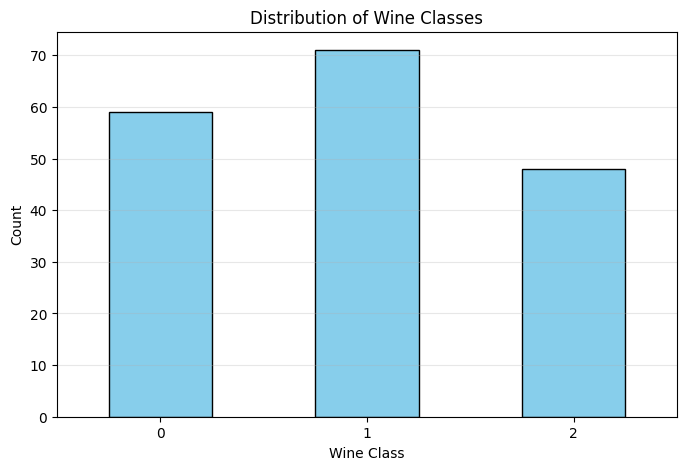

In [6]:
# Exercise 1: Load and Explore the Wine Dataset
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()

# Create DataFrame with features and target
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

# Display the shape of the data
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Display the first 5 rows
print("\nFirst 5 rows of X:")
print(X.head())

# Display class distribution
print("\nClass distribution:")
print(y.value_counts().sort_index())

# Bar plot of class distribution
plt.figure(figsize=(8, 5))
y.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.title('Distribution of Wine Classes')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [3]:
### BEGIN TESTS
assert X.shape == (178, 13)
assert y.shape == (178,)
assert "alcohol" in X.columns
assert set(y.unique()) == {0, 1, 2}
assert y.value_counts().sum() == 178
### END TESTS

### Questions
1. Are the features continuous or categorical?  
2. Looking at the bar plot, do the classes appear balanced or imbalanced?

## Exercise 2: Train-Test Split

Before we can train any model, we need to **split the dataset** into a **training set** and a **testing set**.  

The training set will be used to fit the model, while the testing set will be used to evaluate how well the model generalizes to unseen data.  

**Your tasks:**
- Use <code>train_test_split</code> from <code>sklearn.model_selection</code>.  
- Split the data into <code>X_train</code>, <code>X_test</code>, <code>y_train</code>, <code>y_test</code>.  
- Use <code>test_size=0.2</code>, <code>random_state=42</code>, and **stratify by the target** to preserve class proportions.  
- Print the shapes of the resulting splits.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.model_selection import train_test_split</code></li>
    <li>Use stratified split: <code>X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)</code></li>
    <li>Check the sizes with <code>.shape</code></li>
  </ul>
</details>

In [7]:
# Exercise 2: Train-Test Split with Stratification
from sklearn.model_selection import train_test_split

# Split the data with stratification to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print the shapes of the resulting splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify stratification
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).sort_index())

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)

Class distribution in training set:
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64

Class distribution in test set:
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64


In [5]:
### BEGIN TESTS
assert X_train.shape[0] == 142
assert X_test.shape[0] == 36
assert y_train.shape[0] == 142
assert y_test.shape[0] == 36
# Ensure all labels preserved
assert set(y_train.unique()).union(set(y_test.unique())) == {0,1,2}
# Check stratification roughly
train_counts = y_train.value_counts(normalize=True).sort_index()
test_counts = y_test.value_counts(normalize=True).sort_index()
for i in range(3):
    assert abs(train_counts[i] - test_counts[i]) < 0.05
### END TESTS

### Questions
1. Why is it important to split data into train and test sets?  
2. What is the purpose of stratifying the split by the target variable?

## Exercise 3: KNN Classifier

In this task, we will train two **K-Nearest Neighbors (KNN)** classifiers to predict the wine class:

1. **KNN without scaling**  
2. **KNN with standardized features** using <code>StandardScaler</code>

**Your tasks:**
- Import <code>KNeighborsClassifier</code> and <code>StandardScaler</code> from <code>sklearn</code>.  
- Fit one KNN model on the original training data (<code>X_train, y_train</code>).  
- Fit another KNN model on **scaled features**: scale training features using <code>StandardScaler</code> and transform test features accordingly.  
- Use <code>n_neighbors=5</code> for both models.  
- Predict on the test set and compute **accuracy** for both models.  
- Compare the results and answer why scaling is important for KNN.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.neighbors import KNeighborsClassifier</code>, <code>from sklearn.preprocessing import StandardScaler</code></li>
    <li>Create and fit KNN without scaling: <code>knn = KNeighborsClassifier(n_neighbors=3)</code>, <code>knn.fit(X_train, y_train)</code></li>
    <li>Scale features:
      <code>scaler = StandardScaler()</code>,
      <code>X_train_scaled = scaler.fit_transform(X_train)</code>,
      <code>X_test_scaled = scaler.transform(X_test)</code>
    </li>
    <li>Fit KNN with scaled features: <code>knn_scaled.fit(X_train_scaled, y_train)</code></li>
    <li>Predict and compute accuracy using <code>accuracy_score(y_test, y_pred)</code></li>
  </ul>
</details>

In [8]:
# Exercise 3: KNN Classifier (Scaled vs Unscaled)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# KNN WITHOUT SCALING
knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)
y_pred_knn = knn_no_scaling.predict(X_test)
acc_no_scaling = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy (No Scaling): {acc_no_scaling:.4f}")

# KNN WITH SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled_knn = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled_knn)

print(f"KNN Accuracy (With Scaling): {acc_scaled:.4f}")
print(f"\nImprovement from scaling: {(acc_scaled - acc_no_scaling):.4f}")

KNN Accuracy (No Scaling): 0.8056
KNN Accuracy (With Scaling): 0.9722

Improvement from scaling: 0.1667


In [7]:
### BEGIN TESTS
assert 0 <= acc_no_scaling <= 1
assert 0 <= acc_scaled <= 1
assert y_pred_knn.shape[0] == X_test.shape[0]
assert y_pred_scaled_knn.shape[0] == X_test.shape[0]
### END TESTS

### Questions
1. Why is feature scaling important for K-Nearest Neighbors classifiers? Explain in your own words.
2. Why do we choose `k` to be odd?

## Exercise 4: Decision Tree Classifier

In this task, we will train two **Decision Tree classifiers** to predict the wine class:

1. **Decision Tree without scaling**  
2. **Decision Tree with standardized features** using <code>StandardScaler</code>

**Your tasks:**
- Import <code>DecisionTreeClassifier</code> and <code>StandardScaler</code>.  
- Fit one Decision Tree on the **original training data** (<code>X_train, y_train</code>).  
- Fit another Decision Tree on **scaled features**: scale training features using <code>StandardScaler().fit_transform()</code> and transform the test set accordingly.  
- Predict on the test set and compute **accuracy** for both models.  
- Compare the results and answer whether scaling affected the performance.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.tree import DecisionTreeClassifier</code>, <code>from sklearn.preprocessing import StandardScaler</code></li>
    <li>Create and fit Decision Tree without scaling: <code>dt = DecisionTreeClassifier(random_state=42)</code>, <code>dt.fit(X_train, y_train)</code></li>
    <li>Scale features: <code>scaler = StandardScaler()</code>, <code>X_train_scaled = scaler.fit_transform(X_train)</code>, <code>X_test_scaled = scaler.transform(X_test)</code></li>
    <li>Fit Decision Tree with scaled features: <code>dt_scaled.fit(X_train_scaled, y_train)</code></li>
    <li>Predict and compute accuracy: <code>accuracy_score(y_test, y_pred)</code>, <code>accuracy_score(y_test, y_pred_scaled)</code></li>
  </ul>
</details>

In [9]:
# Exercise 4: Decision Tree Classifier (Scaled vs Unscaled)
from sklearn.tree import DecisionTreeClassifier

# DECISION TREE WITHOUT SCALING
dt_no_scaling = DecisionTreeClassifier(random_state=42)
dt_no_scaling.fit(X_train, y_train)
y_pred_dt = dt_no_scaling.predict(X_test)
acc_dt_no_scaling = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy (No Scaling): {acc_dt_no_scaling:.4f}")

# DECISION TREE WITH SCALING
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_scaled, y_train)
y_pred_scaled_dt = dt_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled_dt)

print(f"Decision Tree Accuracy (With Scaling): {acc_scaled:.4f}")
print(f"\nDifference from scaling: {(acc_scaled - acc_dt_no_scaling):.4f}")
print("\nNote: Decision Trees typically don't require scaling because they make splits based on thresholds,")
print("not on distance or magnitude.")

Decision Tree Accuracy (No Scaling): 0.9444
Decision Tree Accuracy (With Scaling): 0.9444

Difference from scaling: 0.0000

Note: Decision Trees typically don't require scaling because they make splits based on thresholds,
not on distance or magnitude.


In [9]:
### BEGIN TESTS
for acc in [acc_no_scaling, acc_scaled]:
    assert 0 <= acc <= 1
assert y_pred_dt.shape[0] == X_test.shape[0]
assert y_pred_scaled_dt.shape[0] == X_test.shape[0]
### END TESTS

### Questions
1. Do we need scaling for Decision Trees?
2. How could you control overfitting in a Decision Tree?

## Exercise 5: Accuracy and Confusion Matrix

In this task, we will evaluate the performance of a classifier using **accuracy** and a **confusion matrix**.  

**Your tasks:**
- Use the predictions from the **DecisionTree**.  
- Compute the **accuracy** of the predictions on the test set.
- Compute the **confusion matrix**.  
- Display the confusion matrix as a **heatmap** using `seaborn.heatmap` for better visualization.  
- Interpret the results: Which classes are most often misclassified?

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.metrics import confusion_matrix, accuracy_score</code></li>
    <li>Accuracy: <code>accuracy_score(y_test, y_pred)</code></li>
    <li>Confusion matrix: <code>cm = confusion_matrix(y_test, y_pred)</code></li>
    <li>Heatmap visualization: <code>import seaborn as sns; sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')</code></li>
  </ul>
</details>

Accuracy: 0.9444

Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


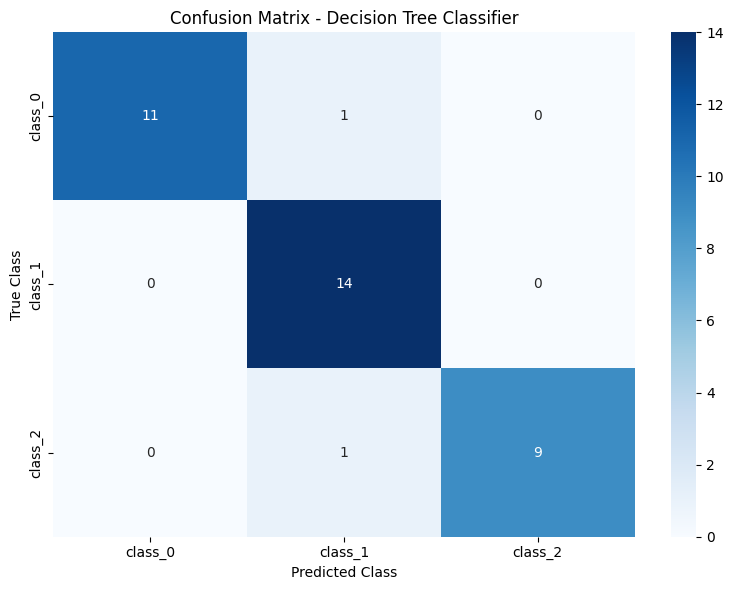


Interpretation:
- Diagonal elements: Correct predictions for each class
- Off-diagonal elements: Misclassifications
- Row sums: Total samples from each true class
- Column sums: Total samples predicted as each class


In [10]:
# Exercise 5: Accuracy and Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score

# Use Decision Tree predictions (from Exercise 4)
# Compute accuracy
acc = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {acc:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix:\n{cm}")

# Visualization as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Diagonal elements: Correct predictions for each class")
print("- Off-diagonal elements: Misclassifications")
print("- Row sums: Total samples from each true class")
print("- Column sums: Total samples predicted as each class")

In [11]:
### BEGIN TESTS
assert 0 <= acc <= 1
assert cm.shape == (3,3)
assert cm.sum() == y_test.shape[0]
### END TESTS

### Questions
1. What does the confusion matrix tell you that accuracy alone cannot?  
2. In which scenario could accuracy be misleading for a classifier?

## Exercise 6: Precision, Recall, and F1 Score

In this task, we will evaluate our classifier using detailed metrics: **precision, recall, and F1 score**.  

**Definitions & Formulas** (for a single class):

- **Precision**: <br>
  <code>Precision = TP / (TP + FP)</code>  
  Measures how many of the predicted positives are actually positive.

- **Recall (Sensitivity)**: <br>
  <code>Recall = TP / (TP + FN)</code>  
  Measures how many of the actual positives are correctly predicted.

- **F1 Score**: <br>
  <code>F1 = 2 * (Precision * Recall) / (Precision + Recall)</code>  
  Harmonic mean of precision and recall.

**Macro vs Weighted averaging**:

- **Macro**: Compute the metric independently for each class, then take the unweighted mean.  
- **Weighted**: Compute the metric for each class, then take a weighted mean based on the number of true instances for each class (class support).

**Your tasks:**
- Compute **precision**, **recall**, and **F1 score** for the test set.  
- Compute both **macro** and **weighted** averages.  
- Discuss which average is more informative for this dataset.

  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.metrics import precision_score, recall_score, f1_score</code></li>
    <li>Macro average: <code>precision_score(y_test, y_pred, average='macro')</code></li>
    <li>Weighted average: <code>precision_score(y_test, y_pred, average='weighted')</code></li>
    <li>Same for recall and F1: <code>recall_score(..., average=...)</code>, <code>f1_score(..., average=...)</code></li>
  </ul>
</details>

In [12]:
# Exercise 6: Precision, Recall, and F1 Score (Macro vs Weighted)
from sklearn.metrics import precision_score, recall_score, f1_score

# Use Decision Tree predictions
# Compute metrics with MACRO averaging
prec_macro = precision_score(y_test, y_pred_dt, average='macro')
rec_macro = recall_score(y_test, y_pred_dt, average='macro')
f1_macro = f1_score(y_test, y_pred_dt, average='macro')

# Compute metrics with WEIGHTED averaging
prec_weighted = precision_score(y_test, y_pred_dt, average='weighted')
rec_weighted = recall_score(y_test, y_pred_dt, average='weighted')
f1_weighted = f1_score(y_test, y_pred_dt, average='weighted')

# Display results in a table
import pandas as pd
results_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Macro Average': [prec_macro, rec_macro, f1_macro],
    'Weighted Average': [prec_weighted, rec_weighted, f1_weighted]
})

print("Classification Metrics Comparison:")
print(results_df.to_string(index=False))

# Per-class metrics
print("\n\nPer-Class Precision (Macro Average):", prec_macro)
print("Per-Class Recall (Macro Average):", rec_macro)
print("Per-Class F1-Score (Macro Average):", f1_macro)
print("\nWeighted Precision:", prec_weighted)
print("Weighted Recall:", rec_weighted)
print("Weighted F1-Score:", f1_weighted)

Classification Metrics Comparison:
   Metric  Macro Average  Weighted Average
Precision       0.958333          0.951389
   Recall       0.938889          0.944444
 F1-Score       0.945741          0.944961


Per-Class Precision (Macro Average): 0.9583333333333334
Per-Class Recall (Macro Average): 0.9388888888888888
Per-Class F1-Score (Macro Average): 0.9457411645054665

Weighted Precision: 0.9513888888888888
Weighted Recall: 0.9444444444444444
Weighted F1-Score: 0.9449614374099499


In [13]:
### BEGIN TESTS
for metric in [prec_macro, prec_weighted, rec_macro, rec_weighted, f1_macro, f1_weighted]:
    assert 0 <= metric <= 1
### END TESTS

### Questions
1. Explain in your own words the difference between **macro** and **weighted** averaging.  
2. Why might F1 score be more informative than accuracy in datasets with imbalanced classes?

## Exercise 7: One-vs-One (OvO) vs One-vs-All (OvA) Strategy

In multiclass classification, some classifiers (like SVM or Logistic Regression) are inherently **binary**, so we need strategies to extend them to multiple classes:

- **One-vs-All (OvA)**: Train one binary classifier per class, where that class is treated as positive and all others as negative.  
- **One-vs-One (OvO)**: Train one binary classifier for every pair of classes.  

Even though Decision Trees can handle multiclass classification inherently, we will use **DecisionTreeClassifier** here to demonstrate these strategies in practice.  

**Your tasks:**
- Use <code>OneVsRestClassifier</code> and <code>OneVsOneClassifier</code> from <code>sklearn.multiclass</code> with a **DecisionTreeClassifier** as the base estimator.  
- Fit both classifiers on the training data.  
- Predict the test set using both classifiers.  
- Compute the **accuracy** for each strategy.  
- Compare the results and discuss which strategy seems better for this dataset.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier</code></li>
    <li>Create base estimator: <code>dt = DecisionTreeClassifier(random_state=42)</code></li>
    <li>OvA: <code>ova = OneVsRestClassifier(dt).fit(X_train, y_train)</code></li>
    <li>OvO: <code>ovo = OneVsOneClassifier(dt).fit(X_train, y_train)</code></li>
    <li>Predict: <code>y_pred_ova = ova.predict(X_test)</code>, <code>y_pred_ovo = ovo.predict(X_test)</code></li>
    <li>Compute accuracy: <code>accuracy_score(y_test, y_pred_ova)</code>, <code>accuracy_score(y_test, y_pred_ovo)</code></li>
  </ul>
</details>

In [14]:
# Exercise 7: One-vs-Rest (OvR) vs One-vs-One (OvO) Strategies
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Create base estimator
base_dt = DecisionTreeClassifier(random_state=42)

# ONE-VS-REST (OvA) Strategy
ova_classifier = OneVsRestClassifier(base_dt)
ova_classifier.fit(X_train, y_train)
y_pred_ova = ova_classifier.predict(X_test)
acc_ova = accuracy_score(y_test, y_pred_ova)

print(f"One-vs-Rest (OvA) Accuracy: {acc_ova:.4f}")
print(f"Number of models trained in OvA: 3 (one for each class)")

# ONE-VS-ONE (OvO) Strategy
ovo_classifier = OneVsOneClassifier(base_dt)
ovo_classifier.fit(X_train, y_train)
y_pred_ovo = ovo_classifier.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

print(f"\nOne-vs-One (OvO) Accuracy: {acc_ovo:.4f}")
print(f"Number of models trained in OvO: 3 (combinations of 2 classes: C(3,2) = 3)")

# Comparison
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"OvA Accuracy: {acc_ova:.4f}")
print(f"OvO Accuracy: {acc_ovo:.4f}")
print(f"Direct Decision Tree Accuracy: {acc_dt_no_scaling:.4f}")
print(f"\nBest strategy for this dataset: ", end="")
if acc_ova >= acc_ovo:
    print(f"One-vs-Rest (OvA)")
else:
    print(f"One-vs-One (OvO)")

One-vs-Rest (OvA) Accuracy: 0.8611
Number of models trained in OvA: 3 (one for each class)

One-vs-One (OvO) Accuracy: 0.8611
Number of models trained in OvO: 3 (combinations of 2 classes: C(3,2) = 3)

COMPARISON
OvA Accuracy: 0.8611
OvO Accuracy: 0.8611
Direct Decision Tree Accuracy: 0.9444

Best strategy for this dataset: One-vs-Rest (OvA)


In [19]:
### BEGIN TESTS
assert 0 <= acc_ova <= 1
assert 0 <= acc_ovo <= 1
assert y_pred_ova.shape[0] == X_test.shape[0]
assert y_pred_ovo.shape[0] == X_test.shape[0]
### END TESTS

### Questions
1. For a dataset with 5 classes, how many models are trained under the One-vs-All (OvA) and One-vs-One (OvO) strategies? As the number of classes increases, which strategy becomes more efficient in terms of computation time?  
2. Based on test accuracy, which strategy seems more effective for this dataset and why?

## Exercise 8: Comparing KNN and Decision Tree Using Classification Report

In this exercise, we will compare the **scaled KNN** and **Decision Tree** classifiers using **classification metrics per class**.  

**Your tasks:**
- Generate a **classification report** for both classifiers using <code>classification_report</code> from <code>sklearn.metrics</code>.    
- Compare the results and discuss:  
  - Which classifier performs better overall?  
  - Are there specific classes where one model is clearly superior?  
  - How do the metrics complement each other in evaluating model performance?

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li>Import: <code>from sklearn.metrics import classification_report</code></li>
    <li>Generate report: <code>print(classification_report(y_test, y_pred_scaled))</code> for KNN</li>
    <li>Generate report for Decision Tree: <code>print(classification_report(y_test, y_pred_dt_scaled))</code></li>
    <li>Compare the metrics per class and overall accuracy</li>
  </ul>
</details>

In [15]:
# Exercise 8: Classification Report - KNN vs Decision Tree
from sklearn.metrics import classification_report

# Generate classification report for SCALED KNN (from Exercise 3)
report_knn = classification_report(y_test, y_pred_scaled_knn, target_names=wine.target_names)
print("=" * 70)
print("CLASSIFICATION REPORT - SCALED KNN CLASSIFIER")
print("=" * 70)
print(report_knn)

# Generate classification report for DECISION TREE (from Exercise 4)
report_dt = classification_report(y_test, y_pred_dt, target_names=wine.target_names)
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - DECISION TREE CLASSIFIER")
print("=" * 70)
print(report_dt)

# Performance comparison summary
print("\n" + "=" * 70)
print("SUMMARY COMPARISON")
print("=" * 70)

# Extract overall accuracy for both
knn_acc = accuracy_score(y_test, y_pred_scaled_knn)
dt_acc = accuracy_score(y_test, y_pred_dt)

comparison_df = pd.DataFrame({
    'Classifier': ['Scaled KNN', 'Decision Tree'],
    'Accuracy': [knn_acc, dt_acc],
    'Winner': ['✓' if knn_acc > dt_acc else '', '✓' if dt_acc > knn_acc else '']
})

print(comparison_df.to_string(index=False))
print(f"\nOverall Better Classifier: {'Scaled KNN' if knn_acc > dt_acc else 'Decision Tree'}")

CLASSIFICATION REPORT - SCALED KNN CLASSIFIER
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


CLASSIFICATION REPORT - DECISION TREE CLASSIFIER
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


SUMMARY COMPARISON
   Classifier  Accuracy Winner
   Scaled KNN  0.972222      ✓
Decision Tree  0.944444       

Overall Better Classifier: S

In [17]:
### BEGIN TESTS
assert isinstance(report_knn, str)
assert isinstance(report_dt, str)
for label in set(y_test):
    assert str(label) in report_knn
    assert str(label) in report_dt
### END TESTS

### Questions
1. Which classifier shows better overall performance according to the classification report?  
2. Are there classes where one model performs clearly better than the other? Give examples.  
3. Why is it useful to look at precision, recall, and F1-score per class instead of just overall accuracy?